In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [4]:
df = pd.read_csv("/content/archive (4).zip")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Shape:", df.shape)
print("\nColumn Info:")
df.info()
print("\nMissing values:\n", df.isnull().sum())

Shape: (7043, 21)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Nulls in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

df.dropna(subset=['TotalCharges'], inplace=True)
df.drop('customerID', axis=1, inplace=True)

print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

print("Shape after cleaning:", df.shape)

Nulls in TotalCharges after conversion: 11
Duplicate rows: 22
Shape after cleaning: (7010, 20)


Churn
No     5153
Yes    1857
Name: count, dtype: int64
Churn
No     73.509272
Yes    26.490728
Name: proportion, dtype: float64


/tmp/ipykernel_757/37801110.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


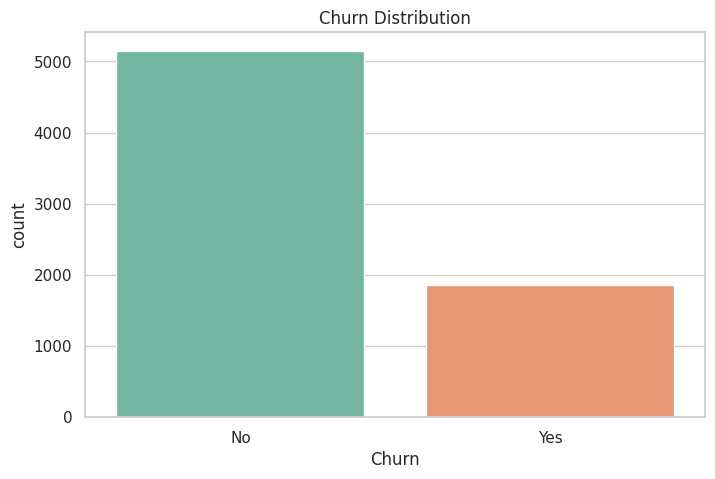

In [7]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.show()

/tmp/ipykernel_757/4227697088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_757/4227697088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_757/4227697088.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2')


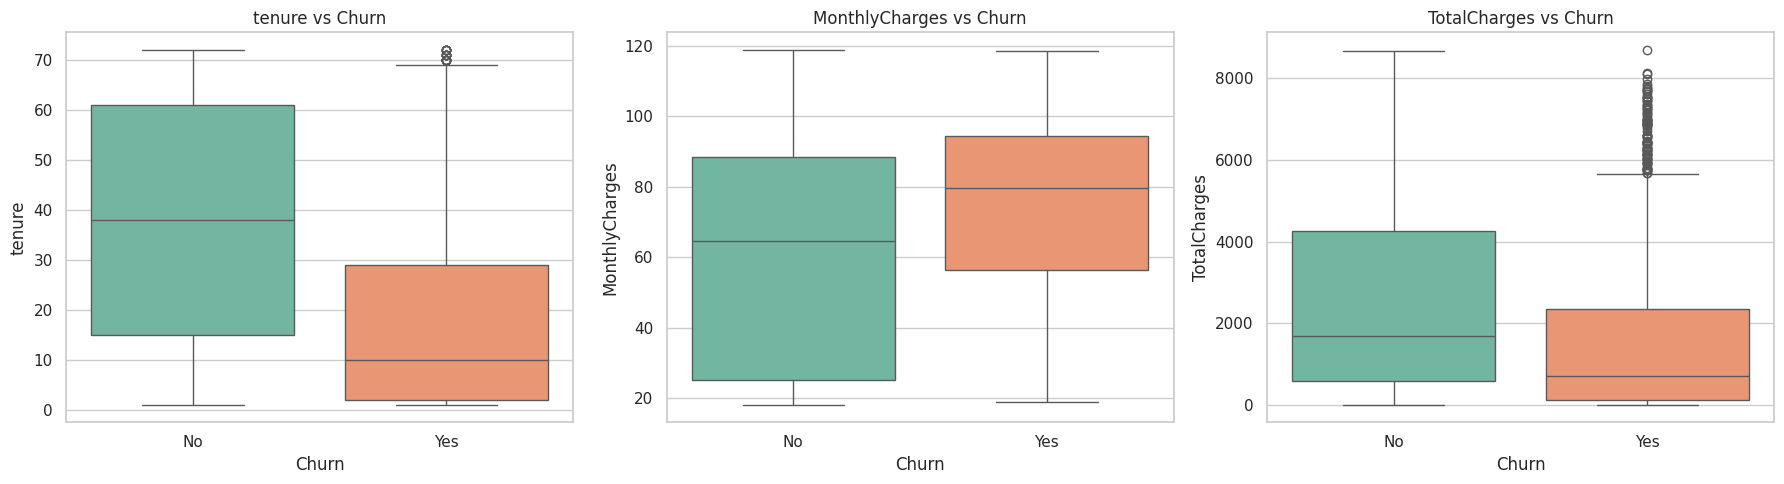

In [8]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

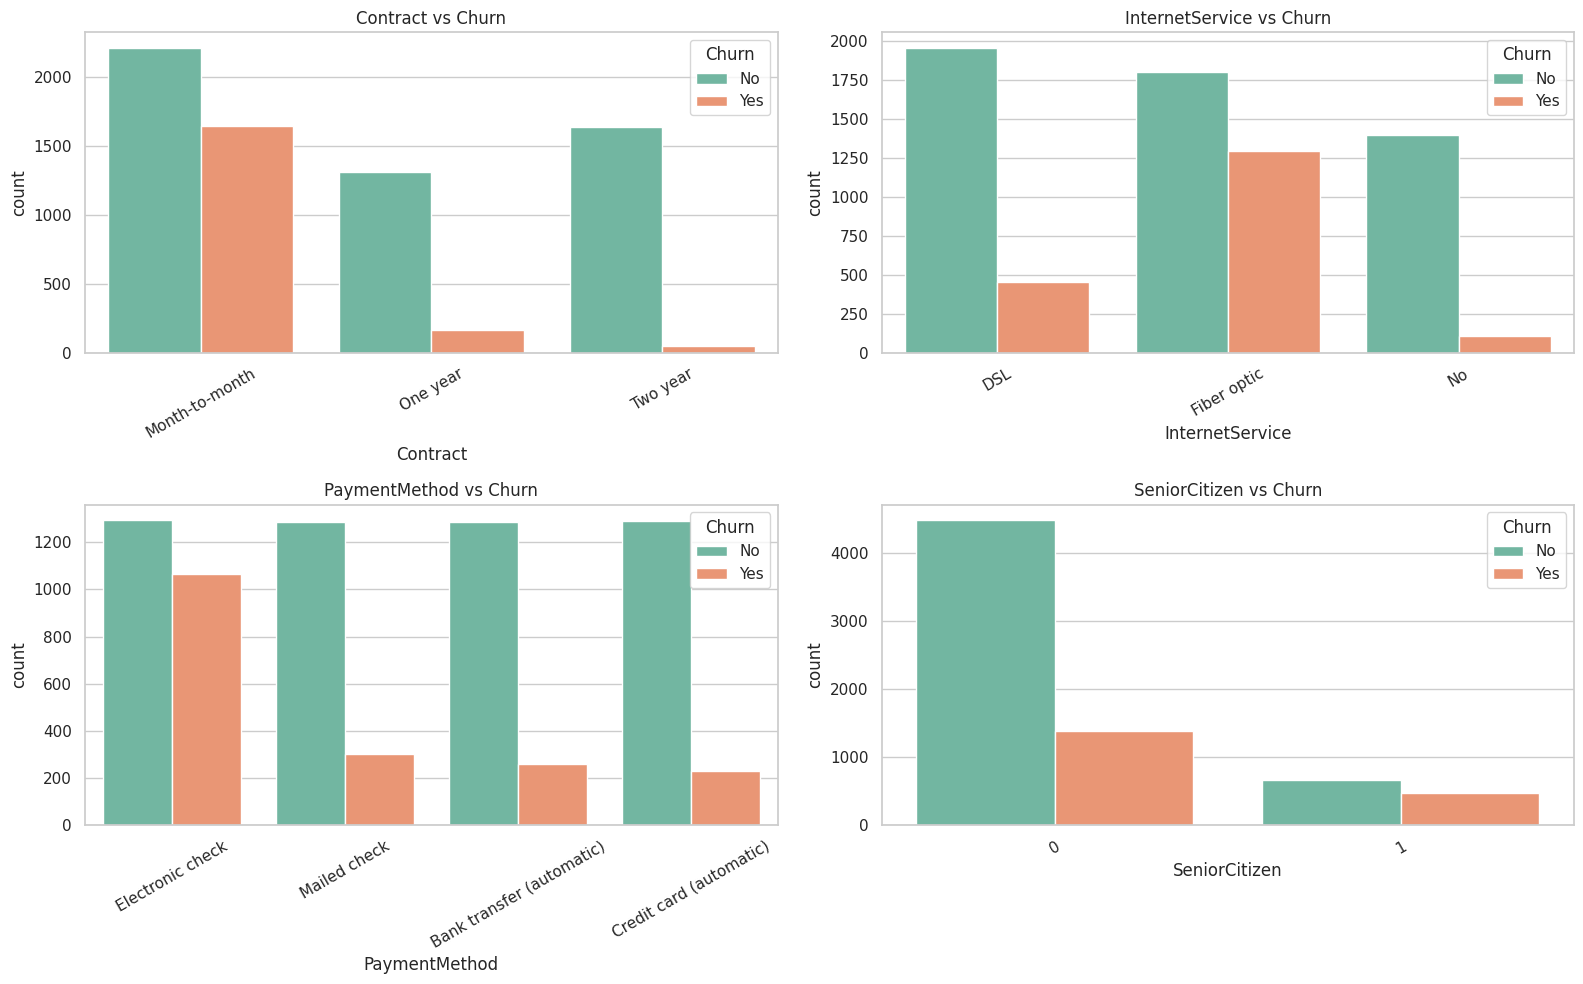

In [9]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

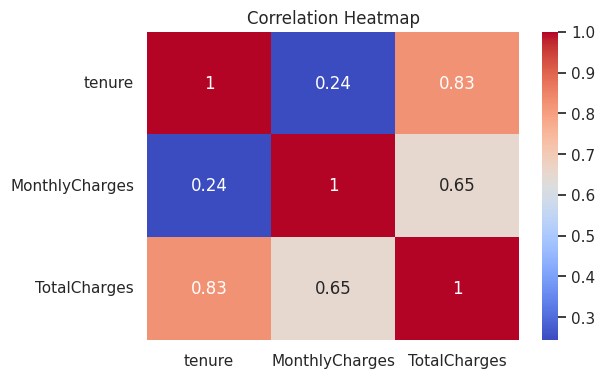

In [10]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
df_fe = df.copy()

def tenure_group(t):
    if t <= 12:
        return '0-1yr'
    elif t <= 24:
        return '1-2yr'
    elif t <= 48:
        return '2-4yr'
    else:
        return '4yr+'

df_fe['TenureGroup'] = df_fe['tenure'].apply(tenure_group)
df_fe['AvgMonthlySpend'] = df_fe['TotalCharges'] / df_fe['tenure'].replace(0, 1)

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_fe['NumServices'] = df_fe[service_cols].apply(lambda row: sum(row == 'Yes'), axis=1)

df_fe['HighRiskCombo'] = ((df_fe['Contract'] == 'Month-to-month') &
                           (df_fe['PaymentMethod'] == 'Electronic check')).astype(int)

print("New features added: TenureGroup, AvgMonthlySpend, NumServices, HighRiskCombo")
df_fe[['TenureGroup', 'AvgMonthlySpend', 'NumServices', 'HighRiskCombo']].head()

New features added: TenureGroup, AvgMonthlySpend, NumServices, HighRiskCombo


,TenureGroup,AvgMonthlySpend,NumServices,HighRiskCombo
0,0-1yr,29.850000,1,1
1,2-4yr,55.573529,2,0
2,0-1yr,54.075000,2,0
3,2-4yr,40.905556,3,0
4,0-1yr,75.825000,0,1


/tmp/ipykernel_757/2823637517.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='NumServices', data=df_fe, ax=axes[1], palette='Set2')


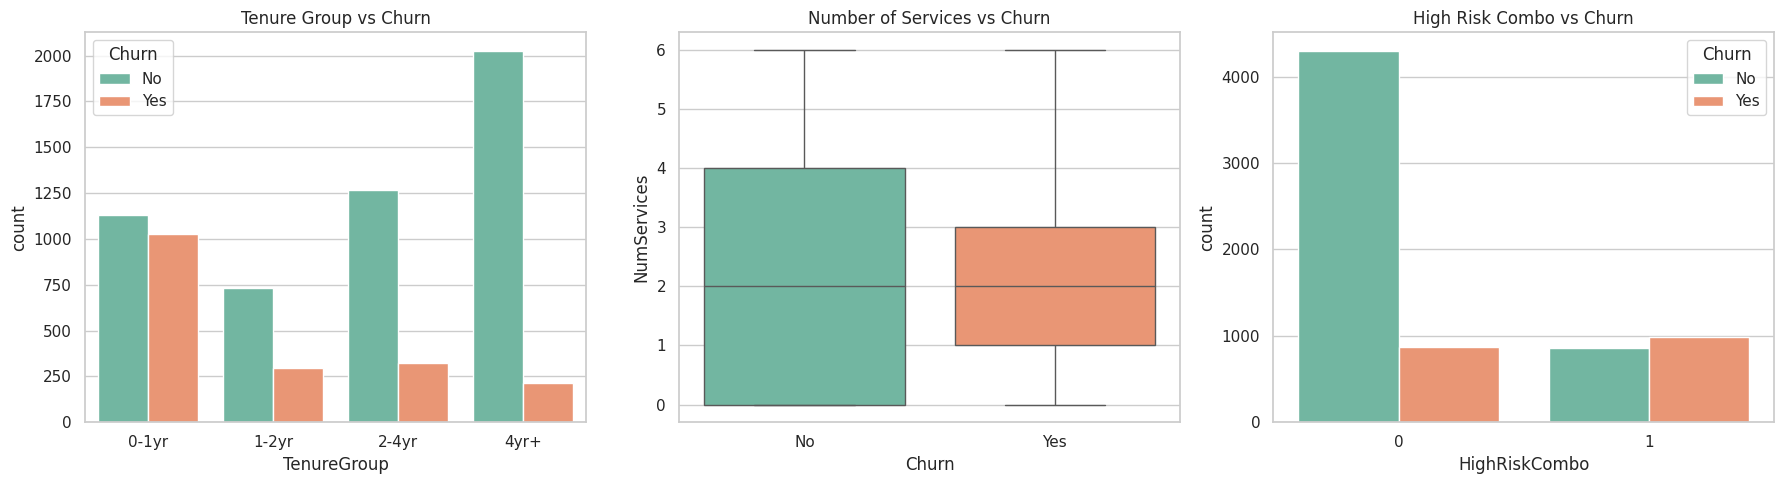

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='TenureGroup', hue='Churn', data=df_fe,
              order=['0-1yr', '1-2yr', '2-4yr', '4yr+'], ax=axes[0], palette='Set2')
axes[0].set_title('Tenure Group vs Churn')

sns.boxplot(x='Churn', y='NumServices', data=df_fe, ax=axes[1], palette='Set2')
axes[1].set_title('Number of Services vs Churn')

sns.countplot(x='HighRiskCombo', hue='Churn', data=df_fe, ax=axes[2], palette='Set2')
axes[2].set_title('High Risk Combo vs Churn')

plt.tight_layout()
plt.show()

In [13]:
df_encoded = df_fe.copy()

binary_cols = df_encoded.select_dtypes(include='object').columns
le = LabelEncoder()

for col in binary_cols:
    if df_encoded[col].nunique() == 2:
        df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded = pd.get_dummies(df_encoded, drop_first=True)

print("Final shape after encoding:", df_encoded.shape)
df_encoded.head()

Final shape after encoding: (7010, 37)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4yr+
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,False,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,False,True,False
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,False,False,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,False,True,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,False,False,False


/tmp/ipykernel_757/2246696125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_scores.head(20).values, y=feature_scores.head(20).index, palette='mako')


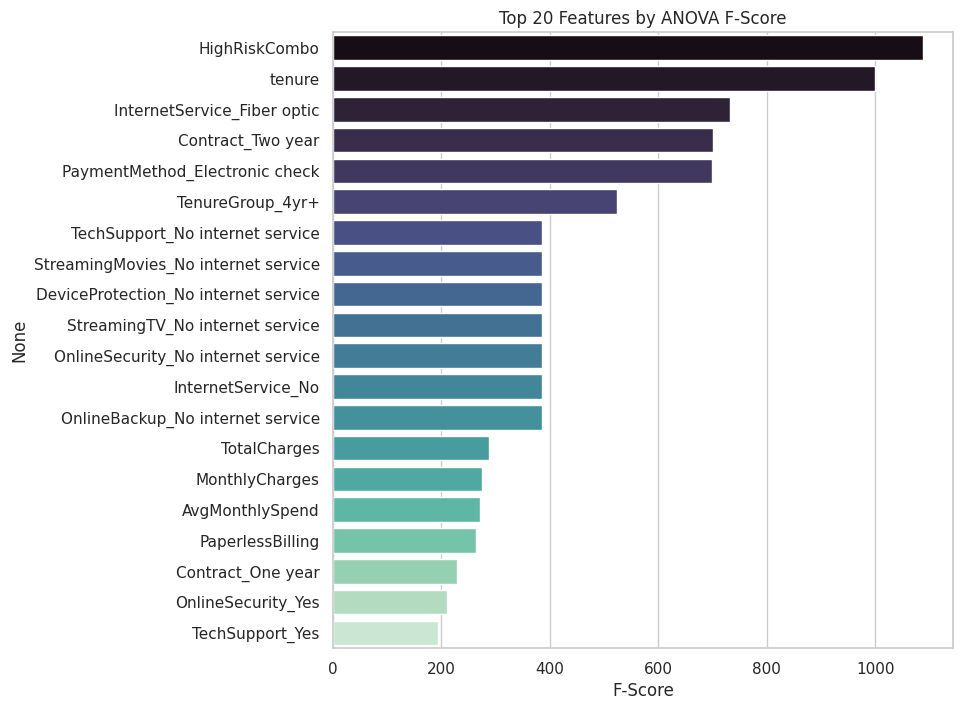

Selected features:
 ['HighRiskCombo', 'tenure', 'InternetService_Fiber optic', 'Contract_Two year', 'PaymentMethod_Electronic check', 'TenureGroup_4yr+', 'TechSupport_No internet service', 'StreamingMovies_No internet service', 'DeviceProtection_No internet service', 'StreamingTV_No internet service', 'OnlineSecurity_No internet service', 'InternetService_No', 'OnlineBackup_No internet service', 'TotalCharges', 'MonthlyCharges', 'AvgMonthlySpend', 'PaperlessBilling', 'Contract_One year', 'OnlineSecurity_Yes', 'TechSupport_Yes']


In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

X_all = df_encoded.drop('Churn', axis=1)
y_all = df_encoded['Churn']

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_all, y_all)

feature_scores = pd.Series(selector.scores_, index=X_all.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=feature_scores.head(20).values, y=feature_scores.head(20).index, palette='mako')
plt.title('Top 20 Features by ANOVA F-Score')
plt.xlabel('F-Score')
plt.show()

top_features = feature_scores.head(20).index.tolist()
print("Selected features:\n", top_features)

X = df_encoded[top_features]
y = y_all

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5608, 20)
Test shape: (1402, 20)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 4122, 1: 1486}
After SMOTE: {0: 4122, 1: 4122}


In [20]:
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

baseline_results = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    baseline_results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, proba)
    }

baseline_df = pd.DataFrame(baseline_results).T
print("Baseline model comparison:")
baseline_df

Baseline model comparison:


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.744650,0.511384,0.787062,0.619958,0.845969
Random Forest,0.763195,0.550129,0.576819,0.563158,0.810133
SVM,0.746077,0.513465,0.770889,0.616379,0.820591


In [29]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    n_iter=10,          # 216 combos ku pathila, random ah 10 dhan try pannum
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_grid.fit(X_train_sm, y_train_sm)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV ROC-AUC:", round(rf_grid.best_score_, 3))

best_rf = rf_grid.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None, 'class_weight': 'balanced'}
Best RF CV ROC-AUC: 0.906


In [30]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_sm, y_train_sm)

print("Best LR Params:", lr_grid.best_params_)
print("Best LR CV ROC-AUC:", round(lr_grid.best_score_, 3))

best_lr = lr_grid.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best LR Params: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR CV ROC-AUC: 0.846



===== Random Forest (Tuned) =====
Accuracy : 0.76
Precision: 0.543
Recall   : 0.593
F1 Score : 0.567
ROC-AUC  : 0.813

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83      1031
           1       0.54      0.59      0.57       371

    accuracy                           0.76      1402
   macro avg       0.70      0.71      0.70      1402
weighted avg       0.77      0.76      0.76      1402



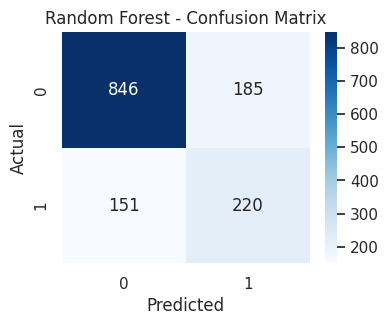


===== Logistic Regression (Tuned) =====
Accuracy : 0.745
Precision: 0.511
Recall   : 0.787
F1 Score : 0.62
ROC-AUC  : 0.846

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81      1031
           1       0.51      0.79      0.62       371

    accuracy                           0.74      1402
   macro avg       0.71      0.76      0.71      1402
weighted avg       0.80      0.74      0.76      1402



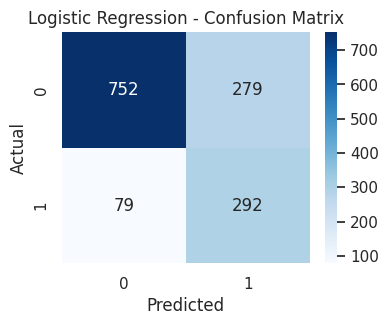

In [31]:
def evaluate_model(name, model, X_test_scaled, y_test):
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n===== {name} (Tuned) =====")
    print("Accuracy :", round(accuracy_score(y_test, preds), 3))
    print("Precision:", round(precision_score(y_test, preds), 3))
    print("Recall   :", round(recall_score(y_test, preds), 3))
    print("F1 Score :", round(f1_score(y_test, preds), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))
    print("\nClassification Report:\n", classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return preds, proba

rf_preds, rf_proba = evaluate_model("Random Forest", best_rf, X_test_scaled, y_test)
lr_preds, lr_proba = evaluate_model("Logistic Regression", best_lr, X_test_scaled, y_test)

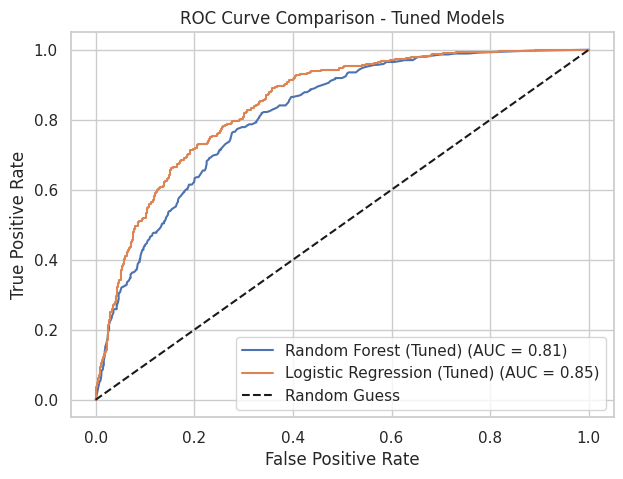

In [32]:
plt.figure(figsize=(7, 5))

for name, proba in [("Random Forest (Tuned)", rf_proba), ("Logistic Regression (Tuned)", lr_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Tuned Models')
plt.legend()
plt.show()

/tmp/ipykernel_757/2632039655.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


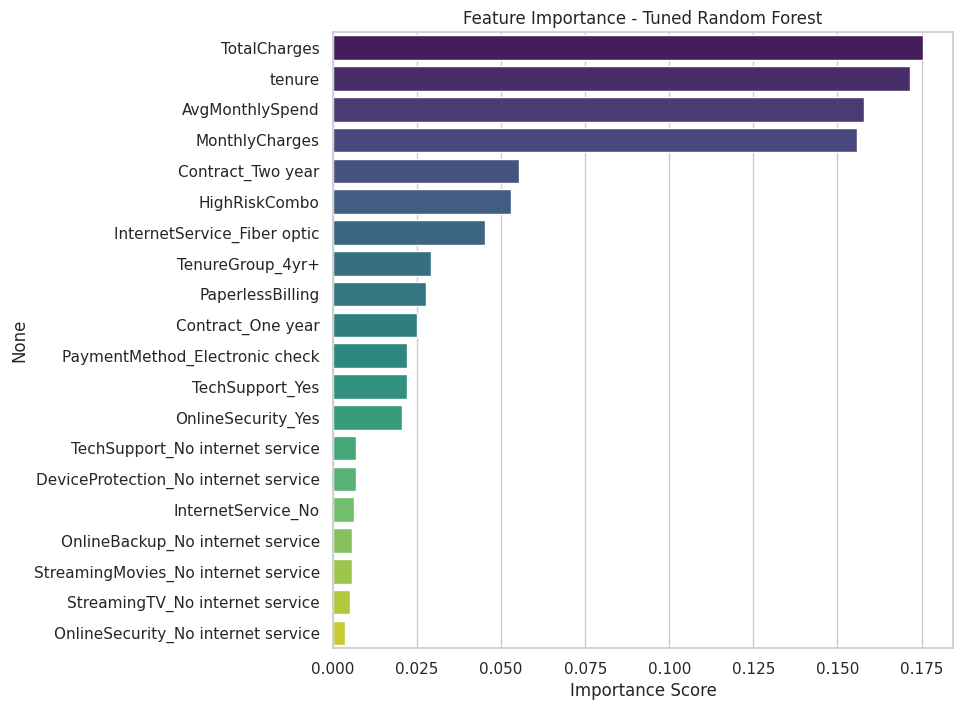

Top 5 churn-driving factors:
TotalCharges         0.175566
tenure               0.171493
AvgMonthlySpend      0.157764
MonthlyCharges       0.155731
Contract_Two year    0.055222
dtype: float64


In [33]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance - Tuned Random Forest')
plt.xlabel('Importance Score')
plt.show()

print("Top 5 churn-driving factors:")
print(importances.head(5))

## Key Churn Factors & Recommendations

**Key Insights** (Cell 21 output paathu update pannunga):
1. Contract type — Month-to-month customers churn far more than 1-2 year contracts.
2. Tenure — Customers in first 0-12 months are at highest churn risk.
3. Payment Method — Electronic check users churn more than auto-pay users.
4. Internet Service — Fiber optic users churn more than DSL users.
5. NumServices — Customers with fewer add-on services churn more.

**Recommendations:**
1. Offer discounted 1-year contract upgrades to month-to-month customers.
2. Strengthen onboarding for first 3-6 months (early churn window).
3. Push customers away from Electronic Check to auto-pay methods.
4. Bundle OnlineSecurity/TechSupport with Fiber optic plans.
5. Use model's churn-probability score to flag high-risk customers proactively.